# Agentic RAG

## Definition

Agentic RAG (Retrieval-Augmented Generation) is a framework that enhances traditional RAG systems by
incorporating intelligent agents to handle complex tasks and make decisions dynamically.

Use an agent to figure out how to retrieve the most relevant information before using the retrieved
information to answer the user's question.

Retrieval Agents are useful when we want to make decisions about whether to retrieve from
an index.

To implement a retrieval agent, we simply need to give an LLM access to a retriever tool.

## Setting Up the Environment

### Importing Required Libraries

In [49]:
### Importing Required Libraries
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN')

### Importing Document Loaders and Vector Store

In [50]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

## Creating the LangGraph Blog Vector Store

### Loading LangGraph Blogs

In [51]:
urls=[
    "https://docs.langchain.com/oss/python/langgraph/overview",
    "https://docs.langchain.com/oss/python/langgraph/workflows-agents",
    "https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api"
]

docs=[WebBaseLoader(url).load() for url in urls]
docs

[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to London on October 13! Get ticketsDocs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceCheckpointersStoresFault toleranceEvent streamingStreamingInterruptsTime travelMemorySubgraphsProductionApplication structureTes

### Combining the Documents

In [52]:
doc_list=[item for sublist in docs for item in sublist]
print(doc_list)

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to London on October 13! Get ticketsDocs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceCheckpointersStoresFault toleranceEvent streamingStreamingInterruptsTime travelMemorySubgraphsProductionApplication structureTest

### Splitting the Documents

In [53]:
text_splitter=RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
doc_splits=text_splitter.split_documents(doc_list)
print(doc_splits)

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to London on October 13! Get ticketsDocs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceCheckpointersStoresFault toleranceEvent streamingStreamingInterruptsTime travelMemorySubgraphsProductionApplication structureTest

### Creating the FAISS Vector Store

In [54]:
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

vectorstore = FAISS.from_documents(
    documents=doc_splits,
    embedding=embeddings
)

retriever = vectorstore.as_retriever()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2308.31it/s]


### Testing the Retriever

In [55]:
retriever.invoke("what is langgraph")

[Document(id='bf88981f-1969-434b-8c45-34d625d28ae9', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='\u200bAcknowledgements\nLangGraph is inspired by Pregel and Apache Beam. The public interface draws inspiration from NetworkX. LangGraph is built by LangChain Inc, the creators of LangChain, but can be used without LangChain.'),
 Document(id='567afb71-5b07-4847-9ba5-a1448552b35a', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph is very low-level, and focused entirely on agent orchestration. Before using LangGraph, we recommend you familiarize yourself with 

### Creating the LangGraph Retriever Tool

In [56]:
from langchain_core.tools import create_retriever_tool
retriever_tool=create_retriever_tool(
    retriever,
    "retriever_vector_db_blog",
    "Search and run information about Langgraph"
)

### Viewing the Retriever Tool

In [57]:
retriever_tool

StructuredTool(name='retriever_vector_db_blog', description='Search and run information about Langgraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x000001A00C8120C0>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x000001A00C811800>)

## Creating the LangChain Blog Vector Store

### Loading LangChain Blogs

In [58]:
langchain_urls=[
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/langchain/agents",
    "https://docs.langchain.com/oss/python/langchain/messages"
]

docs=[WebBaseLoader(url).load() for url in langchain_urls]
docs

[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to London on October 13! Get ticketsDocs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryEvent streamingStreamingStructured outputMiddle

### Combining the Documents

In [59]:
doc_list=[item for sublist in docs for item in sublist]
print(doc_list)

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to London on October 13! Get ticketsDocs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryEvent streamingStreamingStructured outputMiddlew

### Splitting the Documents

In [60]:
text_splitter=RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
doc_splits=text_splitter.split_documents(doc_list)
print(doc_splits)

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to London on October 13! Get ticketsDocs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryEvent streamingStreamingStructured outputMiddlew

### Creating the FAISS Vector Store

In [61]:
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

vectorstorelangchain = FAISS.from_documents(
    documents=doc_splits,
    embedding=embeddings
)

retrieverlangchain = vectorstorelangchain.as_retriever()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1613.55it/s]


### Creating the LangChain Retriever Tool

In [62]:
from langchain_core.tools import create_retriever_tool

retriever_tool_langchain=create_retriever_tool(
    retrieverlangchain,
    "retriever_vector_langchain_blog",
    "Search and run information about Langchain"
)

### Creating the Tools List

In [63]:
tools=[retriever_tool,retriever_tool_langchain]

## Setting Up the Chat Model

In [64]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="qwen/qwen3.8-27b",
    max_tokens=500
)

llm.invoke("Hi")

AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 13, 'total_tokens': 23, 'completion_time': 0.019164941, 'completion_tokens_details': None, 'prompt_time': 0.000611042, 'prompt_tokens_details': None, 'queue_time': 0.047529883, 'total_time': 0.019775983}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_21e59ac2de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a107b3-d76b-7c61-a835-6d2486dd77a3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 10, 'total_tokens': 23})

## Defining the Agent State

In [65]:
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages

from langchain_classic import hub

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

from pydantic import BaseModel, Field

### Creating the Agent State
class AgentState(TypedDict):
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]

## Defining the Agent Node

In [66]:
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    messages = state["messages"]
    model = ChatGroq(model="qwen/qwen3.8-27b")
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

## Defining the Document Grading Node

In [67]:
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = ChatGroq(model="qwen/qwen3.8-27b")

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"

## Defining the Generation Node

In [68]:
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = PromptTemplate.from_template("""
    You are an assistant for question-answering tasks.

    Use the following pieces of retrieved context to answer the question.
    If you don't know the answer, just say that you don't know.
    Use three sentences maximum and keep the answer concise.

    Question: {question}

    Context: {context}

    Answer:
    """)

    # LLM
    llm = ChatGroq(model="qwen/qwen3.8-27b")

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

## Defining the Query Rewrite Node

In [69]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = ChatGroq(model="qwen/qwen3.8-27b")
    response = model.invoke(msg)
    return {"messages": [response]}

## Building the Agentic RAG Workflow

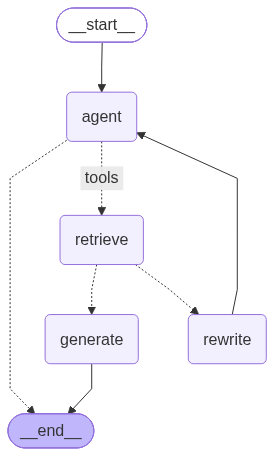

In [70]:
### Importing LangGraph Components
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Creating the StateGraph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriever_tool,retriever_tool_langchain])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant
# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

### Compiling the Workflow
graph = workflow.compile()

### Displaying the Workflow
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


## Testing the Agentic RAG Workflow

### Testing with a LangGraph-Related Query

In [71]:
graph.invoke({"messages":"What is Langgraph?"})

---CALL AGENT---


---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


{'messages': [HumanMessage(content='What is Langgraph?', additional_kwargs={}, response_metadata={}, id='79d3893d-24d7-4058-bdca-ecf41cfc4737'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'q5he0vndv', 'function': {'arguments': '{"query":"What is LangGraph? Overview and key features."}', 'name': 'retriever_vector_db_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 367, 'total_tokens': 405, 'completion_time': 0.115905272, 'completion_tokens_details': None, 'prompt_time': 0.026822454, 'prompt_tokens_details': None, 'queue_time': 0.048325159, 'total_time': 0.142727726}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_a1293f40b5', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a107b3-dc6d-7381-a695-1970e147a9b1-0', tool_calls=[{'name': 'retriever_vector_db_blog', 'args': {'query': 'What is LangGraph? Overview and key features.'}

### Testing with a LangChain-Related Query

In [72]:
graph.invoke({"messages":"What is Langchain?"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


{'messages': [HumanMessage(content='What is Langchain?', additional_kwargs={}, response_metadata={}, id='c54f07b0-95f5-4547-8e3d-f20c3aa99cb6'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'arnqwnj5m', 'function': {'arguments': '{"query":"What is Langchain?"}', 'name': 'retriever_vector_langchain_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 367, 'total_tokens': 401, 'completion_time': 0.095698179, 'completion_tokens_details': None, 'prompt_time': 0.025921392, 'prompt_tokens_details': None, 'queue_time': 0.051039781, 'total_time': 0.121619571}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_424cb89518', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a107b3-e202-7fb0-a91d-054a3d70426e-0', tool_calls=[{'name': 'retriever_vector_langchain_blog', 'args': {'query': 'What is Langchain?'}, 'id': 'arnqwnj5m', 'type': 'tool_call'

**Why does it use the retriever?**

The query is related to LangGraph / LangChain, which is covered by the documents stored in the vector database. Therefore, the agent decides to call the retriever, checks the relevance of the retrieved documents, and then generates the final response.

### Testing with an Unrelated Query

In [73]:
graph.invoke({"messages":"What is Machine learning?"})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Machine learning?', additional_kwargs={}, response_metadata={}, id='b867676f-7b9d-464b-849a-ae23b3adebae'),
  AIMessage(content='Machine learning (ML) is a branch of artificial intelligence (AI) that enables systems to learn and improve from experience without being explicitly programmed. Instead of following fixed rules, ML algorithms analyze data, identify patterns, and use those patterns to make predictions or decisions.\n\nIn simple terms:\n- **Traditional programming**: You give the computer rules and data, and it produces answers.\n- **Machine learning**: You give the computer data and answers, and it learns the rules to produce new answers.\n\nCommon types of machine learning include:\n1. **Supervised learning** – Learning from labeled data (e.g., classifying emails as spam or not spam).\n2. **Unsupervised learning** – Finding patterns in data without labels (e.g., customer segmentation).\n3. **Reinforcement learning** – Learning by in

### Testing with an Unrelated Query

In [74]:
graph.invoke({"messages":"Who is Iron Man?"})

---CALL AGENT---


{'messages': [HumanMessage(content='Who is Iron Man?', additional_kwargs={}, response_metadata={}, id='5f4bbf9c-b7fd-46b0-a8af-56be014530e3'),
  AIMessage(content='Iron Man is a popular superhero in the Marvel universe. His real name is Tony Stark, a billionaire industrialist, genius inventor, and the founder of Stark Industries.\n\nIn the story, Iron Man is a popular superhero in the Marvel universe. His real name is Tony Stark, a billionaire industrialist, genius inventor, and the founder of Stark Industries. He created a high-tech suit of armor that gives him superhuman strength, flight, and various advanced weapons and technologies.\n\nIron Man is known for his intelligence, wit, and technological prowess. He is a key member of the Avengers and has been featured in numerous comic books, movies, and other media.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 134, 'prompt_tokens': 367, 'total_tokens': 501, 'completion_time': 0.262874325, 'completion_t

**Why does it not use the retriever?**

The query is unrelated to the LangGraph/LangChain documentation stored in the vector database. Therefore, the agent does not make a tool call and directly generates a response using the LLM.